In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

In [49]:
df=pd.read_csv(r"C:\Users\anant\OneDrive\Desktop\IRIS.csv")
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [50]:
#averagde sepal length of all flowers
df["SepalLengthCm"].median()

5.8

In [51]:
#species having highest petal width
pw=df["PetalWidthCm"].median()
print("avg petal width",pw)

avg petal width 1.3


In [52]:
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [53]:
df.duplicated().sum() 

np.int64(0)

In [75]:
#label encoding
from sklearn.preprocessing import LabelEncoder

In [83]:
# Initialize the encoder
le = LabelEncoder()

# Apply encoding on the target column
df['species_encoded'] = le.fit_transform(df['Species'])

print(df.head())

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species  \
0   1            5.1           3.5            1.4           0.2  Iris-setosa   
1   2            4.9           3.0            1.4           0.2  Iris-setosa   
2   3            4.7           3.2            1.3           0.2  Iris-setosa   
3   4            4.6           3.1            1.5           0.2  Iris-setosa   
4   5            5.0           3.6            1.4           0.2  Iris-setosa   

   species_encoded  
0                0  
1                0  
2                0  
3                0  
4                0  


In [84]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,species_encoded
0,1,5.1,3.5,1.4,0.2,Iris-setosa,0
1,2,4.9,3.0,1.4,0.2,Iris-setosa,0
2,3,4.7,3.2,1.3,0.2,Iris-setosa,0
3,4,4.6,3.1,1.5,0.2,Iris-setosa,0
4,5,5.0,3.6,1.4,0.2,Iris-setosa,0


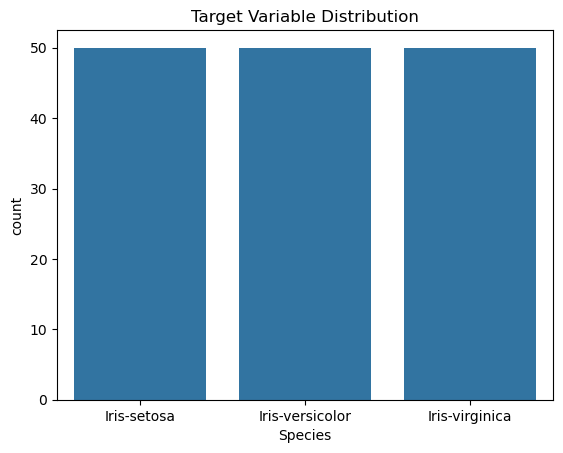

In [85]:
sns.countplot(x='Species', data=df)
plt.title("Target Variable Distribution")
plt.show()

In [86]:
#less data imbalance

In [135]:
#here the more amount of data is nonlinear so spearman correlation is applied
feature_target_corr = df.corr(method='spearman')['species_encoded'].sort_values(ascending=False)

print("Correlation of features with target:")
print(feature_target_corr)

ValueError: could not convert string to float: 'Iris-setosa'

In [88]:
# Dependent variable (target)
y = df['Species']

# Independent variables (features)
X = df[['PetalWidthCm', 'PetalLengthCm', 'SepalLengthCm']]

In [89]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [62]:
# Scale features for better KNN performance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [63]:
# Split into train-test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)


In [118]:
# Initialize KNN model
knn = KNeighborsClassifier(n_neighbors=5)

In [119]:
# Train the model
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [120]:
# Predict on test set
y_pred = knn.predict(X_test)

In [121]:
# Evaluate performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9333333333333333

Confusion Matrix:
 [[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]

Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.83      1.00      0.91        10
 Iris-virginica       1.00      0.80      0.89        10

       accuracy                           0.93        30
      macro avg       0.94      0.93      0.93        30
   weighted avg       0.94      0.93      0.93        30



In [117]:
#checking overfitting 
# Calculate training and testing accuracy
train_acc = knn.score(X_train, y_train)
test_acc = knn.score(X_test, y_test)

print(f"Training Accuracy: {train_acc:.3f}")
print(f"Testing Accuracy: {test_acc:.3f}")


Training Accuracy: 0.967
Testing Accuracy: 0.933


In [110]:
pip install ydata_profiling


Note: you may need to restart the kernel to use updated packages.


In [111]:
from ydata_profiling import ProfileReport  
# Generate profile report
profile = ProfileReport(df)
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|███████████████████████████████████████████████████████████████████████████████████| 7/7 [00:00<00:00, 111.24it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

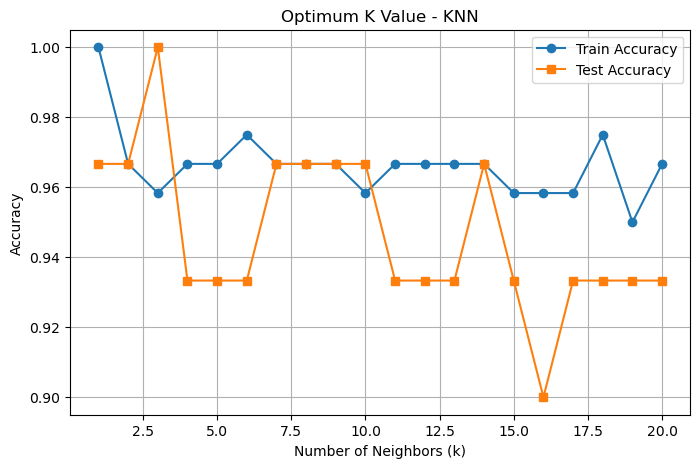

✅ Optimum K Value: 3
Test Accuracy at K=3: 1.000


In [115]:
# Check accuracy for different k values
k_values = range(1, 21)
train_acc = []
test_acc = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    train_acc.append(knn.score(X_train, y_train))
    test_acc.append(knn.score(X_test, y_test))

# Plot accuracy vs K
plt.figure(figsize=(8,5))
plt.plot(k_values, train_acc, marker='o', label='Train Accuracy')
plt.plot(k_values, test_acc, marker='s', label='Test Accuracy')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.title('Optimum K Value - KNN')
plt.legend()
plt.grid(True)
plt.show()

# Find best K
best_k = k_values[test_acc.index(max(test_acc))]
print(f"✅ Optimum K Value: {best_k}")
print(f"Test Accuracy at K={best_k}: {max(test_acc):.3f}")

In [128]:
# Initialize KNN model
knn = KNeighborsClassifier(n_neighbors=3)

In [129]:
# Train the model
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [130]:
# Predict on test set
y_pred = knn.predict(X_test)

In [131]:
# Evaluate performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0

Confusion Matrix:
 [[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]

Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



In [134]:
#best k value is 3 so by applying it we get an accuracy of 1